# 4-Node Motif Census on LLM Attribution Graphs with Capability Clustering

This notebook demonstrates the **4-node directed motif census** on LLM attribution graphs from the Neuronpedia corpus (gemma-2-2b, 8 capability domains).

**What it does:**
1. Builds directed graphs from Neuronpedia attribution data (pre-pruned at 99th percentile)
2. Computes 3-node and 4-node motif census using igraph
3. Generates degree-preserving DAG null models (Goni Method 1) with edge swaps
4. Computes Z-scores and significance profiles (SP)
5. Compares clustering quality (NMI) across feature sets: 4-node SP/Z-scores, 3-node enriched features, graph statistics baseline, and random
6. Tests hypotheses about universal motif overrepresentation and capability clustering

**Key findings:** 4-node motifs provide a richer 24D structural vocabulary vs degenerate 3-node SP (constant [-0.5,-0.5,-0.5,0.5]). 4/24 motif types are universally overrepresented across domains.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# igraph — NOT on Colab, always install
_pip('igraph==0.11.8')

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
# scipy version adjusted for Python <3.11 compatibility (Colab uses 3.12)
if 'google.colab' not in sys.modules:
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import sys
import os
import gc
import math
import random
import time
from collections import defaultdict, Counter
from typing import Any

import numpy as np
from loguru import logger

import igraph
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, rbf_kernel
from sklearn.manifold import TSNE
from scipy.stats import f_oneway
from scipy.spatial.distance import cosine as cos_dist
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter3_4_node_motif_ce/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data)} graphs")
domain_counts = Counter(r["domain"] for r in data)
for d, c in sorted(domain_counts.items()):
    print(f"  {d}: {c} graphs")

Loaded 16 graphs
  antonym: 2 graphs
  arithmetic: 2 graphs
  code_completion: 2 graphs
  country_capital: 2 graphs
  multi_hop_reasoning: 2 graphs
  rhyme: 2 graphs
  sentiment: 2 graphs
  translation: 2 graphs


In [5]:
# ============================================================
# CONFIGURATION — all tunable parameters
# ============================================================
# Scaled values for meaningful demo; original values in comments.

N_NULL_3 = 10          # original: 30  — number of 3-node null models per graph
N_NULL_4 = 10          # original: 50  — number of 4-node null models per graph
SWAP_MULTIPLIER = 100  # original: 100 — edge-swap attempts = SWAP_MULTIPLIER * n_edges
MAX_4NODE_NODES = 500  # original: 500 — skip 4-node census for graphs larger than this
CLUSTER_K_VALUES = [2, 4, 8]  # original: [2, 3, 4, 6, 8]
SEED = 42
N_WORKERS = 1          # original: max(1, NUM_CPUS - 1) — parallel workers for null models

## Build Isoclass Mappings and Igraph Objects

Enumerate all 3-node (16 classes) and 4-node (218 classes) directed subgraph isomorphism classes. Identify which are both connected and DAG-valid. Then build igraph objects from the loaded graph data.

In [6]:
def build_isoclass_mapping(size: int) -> tuple[dict, list[int]]:
    """Build mapping from igraph isoclass ID to graph properties."""
    n_classes = 16 if size == 3 else 218
    mapping: dict[int, dict] = {}
    dag_valid_connected: list[int] = []

    for cls_id in range(n_classes):
        g = igraph.Graph.Isoclass(n=size, cls=cls_id, directed=True)
        edge_list = g.get_edgelist()
        n_edges = len(edge_list)
        is_connected = g.is_connected(mode="weak")
        is_dag_val = g.is_dag()

        mapping[cls_id] = {
            "edges": edge_list,
            "n_edges": n_edges,
            "is_connected": is_connected,
            "is_dag": is_dag_val,
        }

        if is_connected and is_dag_val:
            dag_valid_connected.append(cls_id)

    return mapping, dag_valid_connected


def identify_3node_man_labels(mapping: dict, dag_valid: list[int]) -> dict[int, str]:
    """Identify MAN labels for 3-node DAG-valid types by edge/degree structure."""
    names: dict[int, str] = {}
    for cls_id in dag_valid:
        n_edges = mapping[cls_id]["n_edges"]
        edges = mapping[cls_id]["edges"]
        g = igraph.Graph(n=3, edges=edges, directed=True)
        in_degs = g.indegree()
        out_degs = g.outdegree()

        if n_edges == 3:
            names[cls_id] = "030T"
        elif n_edges == 2:
            if max(out_degs) == 2:
                names[cls_id] = "021D"
            elif max(in_degs) == 2:
                names[cls_id] = "021U"
            else:
                names[cls_id] = "021C"
        else:
            names[cls_id] = f"unknown_{n_edges}edges"

    return names


def build_igraph(record: dict, prune_percentile: int) -> igraph.Graph:
    """Build a pruned igraph.Graph from a parsed graph record."""
    nodes = record["nodes"]
    links = record["links"]

    node_ids = [n["node_id"] for n in nodes]
    node_id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
    layers = []
    feature_types = []
    for n in nodes:
        layer_val = n.get("layer", 0)
        try:
            layers.append(int(layer_val))
        except (ValueError, TypeError):
            layers.append(0)
        feature_types.append(n.get("feature_type", ""))

    all_weights = [abs(link.get("weight", 0.0)) for link in links]
    if not all_weights:
        threshold = 0.0
    else:
        threshold = float(np.percentile(all_weights, prune_percentile))

    edges = []
    edge_weights = []
    for link in links:
        w = abs(link.get("weight", 0.0))
        if w >= threshold:
            src_idx = node_id_to_idx.get(link["source"])
            tgt_idx = node_id_to_idx.get(link["target"])
            if src_idx is not None and tgt_idx is not None and src_idx != tgt_idx:
                edges.append((src_idx, tgt_idx))
                edge_weights.append(w)

    g = igraph.Graph(n=len(node_ids), edges=edges, directed=True)
    g.vs["node_id"] = node_ids
    g.vs["layer"] = layers
    g.vs["feature_type"] = feature_types
    if edge_weights:
        g.es["weight"] = edge_weights

    g = g.simplify(multiple=True, loops=True, combine_edges="max")

    isolated = [v.index for v in g.vs if g.degree(v) == 0]
    if isolated:
        g.delete_vertices(isolated)

    if not g.is_dag():
        raise ValueError(f"Graph is not DAG after pruning at {prune_percentile}%")

    return g


# Build isoclass mappings
mapping_3, dag_valid_3 = build_isoclass_mapping(3)
names_3 = identify_3node_man_labels(mapping_3, dag_valid_3)
logger.info(f"3-node DAG-valid connected types: {len(dag_valid_3)} IDs: {dag_valid_3}")
for cls_id in dag_valid_3:
    logger.info(f"  ID {cls_id}: {names_3[cls_id]} (edges: {mapping_3[cls_id]['edges']})")

mapping_4, dag_valid_4 = build_isoclass_mapping(4)
logger.info(f"4-node DAG-valid connected types: {len(dag_valid_4)} IDs: {dag_valid_4}")

dag_impossible_3 = [
    cls_id for cls_id in range(16)
    if mapping_3[cls_id]["is_connected"] and not mapping_3[cls_id]["is_dag"]
]

ffl_id = [mid for mid in dag_valid_3 if names_3[mid] == "030T"][0]
logger.info(f"Feed-forward loop (030T) isoclass ID: {ffl_id}")

# Build igraph objects from loaded data (data is pre-pruned at 99%,
# so prune_percentile=0 keeps all edges)
graphs: dict[int, igraph.Graph] = {}
for i, rec in enumerate(data):
    try:
        g = build_igraph(rec, 0)
        graphs[i] = g
    except Exception as e:
        logger.warning(f"Failed building graph {i} ({rec['domain']}): {e}")

logger.info(f"Built {len(graphs)} igraph objects")
if graphs:
    node_counts = [g.vcount() for g in graphs.values()]
    logger.info(f"  Nodes: min={min(node_counts)}, median={np.median(node_counts):.0f}, max={max(node_counts)}")

01:12:28|INFO   |3-node DAG-valid connected types: 4 IDs: [2, 4, 6, 7]


01:12:28|INFO   |  ID 2: 021U (edges: [(2, 0), (1, 0)])


01:12:28|INFO   |  ID 4: 021C (edges: [(0, 1), (2, 0)])


01:12:28|INFO   |  ID 6: 021D (edges: [(2, 1), (2, 0)])


01:12:28|INFO   |  ID 7: 030T (edges: [(2, 1), (2, 0), (1, 0)])


01:12:28|INFO   |4-node DAG-valid connected types: 24 IDs: [3, 7, 12, 13, 14, 17, 19, 20, 24, 29, 35, 41, 42, 47, 52, 58, 66, 67, 76, 77, 78, 80, 82, 83]


01:12:28|INFO   |Feed-forward loop (030T) isoclass ID: 7


01:12:28|INFO   |Built 16 igraph objects


01:12:28|INFO   |  Nodes: min=171, median=396, max=864


## Motif Census, Null Models, and Z-Scores

Run 3-node and 4-node motif census on each graph. Generate degree-preserving DAG null models using edge swaps (Goni Method 1), then compute Z-scores and significance profiles (SP).

In [7]:
def compute_motif_census(
    g: igraph.Graph, size: int, dag_valid_ids: list[int]
) -> dict[int, int]:
    """Run motifs_randesu, extract counts for DAG-valid connected types."""
    raw = g.motifs_randesu(size=size)
    counts = [0 if (x != x) else int(x) for x in raw]
    valid_counts = {idx: counts[idx] for idx in dag_valid_ids}
    return valid_counts


def _generate_null_edges(
    n_nodes: int, edges: list[tuple[int, int]], topo_rank: list[int],
    n_swap_attempts: int, seed: int,
) -> tuple[list[tuple[int, int]], int]:
    """Generate one DAG-preserving random graph via degree-preserving edge swaps."""
    rng = random.Random(seed)
    edge_list = list(edges)
    n_edges = len(edge_list)
    if n_edges < 2:
        return edge_list, 0

    adj_set = set(edge_list)
    accepted = 0

    for _ in range(n_swap_attempts):
        i1 = rng.randint(0, n_edges - 1)
        i2 = rng.randint(0, n_edges - 1)
        if i1 == i2:
            continue

        u1, v1 = edge_list[i1]
        u2, v2 = edge_list[i2]

        if u1 == u2 or v1 == v2:
            continue

        new_e1 = (u1, v2)
        new_e2 = (u2, v1)

        if new_e1 in adj_set or new_e2 in adj_set:
            continue

        if topo_rank[u1] >= topo_rank[v2] or topo_rank[u2] >= topo_rank[v1]:
            continue

        adj_set.discard((u1, v1))
        adj_set.discard((u2, v2))
        adj_set.add(new_e1)
        adj_set.add(new_e2)

        edge_list[i1] = new_e1
        edge_list[i2] = new_e2
        accepted += 1

    return edge_list, accepted


def generate_null_census(
    g: igraph.Graph, size: int, dag_valid_ids: list[int], n_null: int,
) -> list[dict[int, int]]:
    """Generate n_null null models sequentially and return their motif censuses."""
    n_nodes = g.vcount()
    edges = [tuple(e.tuple) for e in g.es]

    topo_order = g.topological_sorting()
    topo_rank = [0] * n_nodes
    for rank, node in enumerate(topo_order):
        topo_rank[node] = rank

    n_swap_attempts = SWAP_MULTIPLIER * len(edges)

    results = []
    for seed in range(n_null):
        new_edges, _accepted = _generate_null_edges(
            n_nodes, edges, topo_rank, n_swap_attempts, seed
        )
        g_null = igraph.Graph(n=n_nodes, edges=new_edges, directed=True)
        raw = g_null.motifs_randesu(size=size)
        counts = [0 if (x != x) else int(x) for x in raw]
        census = {idx: counts[idx] for idx in dag_valid_ids}
        results.append(census)
        del g_null

    return results


def compute_zscores_and_sp(
    real_counts: dict[int, int], null_counts_list: list[dict[int, int]],
    dag_valid_ids: list[int],
) -> dict[str, Any]:
    """Compute Z-scores, empirical p-values, and significance profiles."""
    z_scores: dict[int, float] = {}
    p_values: dict[int, float] = {}

    for motif_id in dag_valid_ids:
        real_val = real_counts[motif_id]
        null_vals = np.array([nc[motif_id] for nc in null_counts_list], dtype=float)

        mean_null = float(np.mean(null_vals))
        std_null = float(np.std(null_vals))

        if std_null == 0:
            if real_val == mean_null:
                z = 0.0
            else:
                z = 10.0 if real_val > mean_null else -10.0
        else:
            z = (real_val - mean_null) / std_null

        z_scores[motif_id] = float(z)
        p = float(np.sum(null_vals >= real_val) / len(null_vals))
        p_values[motif_id] = p

    z_vec = np.array([z_scores[mid] for mid in dag_valid_ids])
    z_norm = float(np.linalg.norm(z_vec))

    if z_norm == 0:
        sp = {mid: 0.0 for mid in dag_valid_ids}
    else:
        sp = {mid: float(z_scores[mid] / z_norm) for mid in dag_valid_ids}

    return {
        "z_scores": z_scores,
        "p_values": p_values,
        "sp": sp,
        "z_norm": z_norm,
        "raw_counts": real_counts,
        "null_means": {
            mid: float(np.mean([nc[mid] for nc in null_counts_list]))
            for mid in dag_valid_ids
        },
        "null_stds": {
            mid: float(np.std([nc[mid] for nc in null_counts_list]))
            for mid in dag_valid_ids
        },
    }


# ---- Run 3-node census ----
t_start = time.time()
logger.info("Running 3-node motif census...")
real_census_3: dict[int, dict[int, int]] = {}
for gi, g in graphs.items():
    real_census_3[gi] = compute_motif_census(g, 3, dag_valid_3)
logger.info(f"  3-node census done for {len(real_census_3)} graphs")

# ---- 3-node null models + Z-scores ----
logger.info(f"Generating {N_NULL_3} null models per graph (3-node)...")
null_census_3: dict[int, list[dict[int, int]]] = {}
for idx, gi in enumerate(sorted(graphs.keys())):
    g = graphs[gi]
    null_census_3[gi] = generate_null_census(g, 3, dag_valid_3, N_NULL_3)
    if (idx + 1) % 5 == 0 or idx == 0:
        logger.info(f"  [{idx+1}/{len(graphs)}] Graph {gi}: done ({g.vcount()}n, {g.ecount()}e)")

results_3node: dict[int, dict] = {}
for gi in real_census_3:
    if gi in null_census_3 and null_census_3[gi]:
        stats = compute_zscores_and_sp(real_census_3[gi], null_census_3[gi], dag_valid_3)
        stats["domain"] = data[gi]["domain"]
        results_3node[gi] = stats

logger.info(f"3-node Z-scores computed for {len(results_3node)} graphs")
for mid in dag_valid_3:
    z_vals = [results_3node[gi]["z_scores"][mid] for gi in results_3node]
    if z_vals:
        logger.info(f"  {names_3[mid]} (ID {mid}): mean Z={np.mean(z_vals):.2f} +/- {np.std(z_vals):.2f}")

# ---- 4-node census (raw counts only for speed) ----
logger.info("Running 4-node motif census...")
real_census_4: dict[int, dict[int, int]] = {}
census_method: dict[int, str] = {}

for gi, g in sorted(graphs.items()):
    n = g.vcount()
    if n > MAX_4NODE_NODES:
        census_method[gi] = "skipped_too_large"
        continue
    try:
        t0 = time.time()
        census = compute_motif_census(g, 4, dag_valid_4)
        elapsed = time.time() - t0
        real_census_4[gi] = census
        census_method[gi] = f"exact_{elapsed:.1f}s"
        logger.info(f"  Graph {gi} ({n}n): 4-node census in {elapsed:.1f}s")
    except Exception as e:
        census_method[gi] = "failed"
        logger.warning(f"  Graph {gi}: failed: {e}")

n_exact = sum(1 for v in census_method.values() if v.startswith("exact"))
n_skipped = sum(1 for v in census_method.values() if v.startswith("skipped"))
logger.info(f"  4-node census: {len(real_census_4)} done (exact={n_exact}, skipped={n_skipped})")

# ---- 4-node null models (if N_NULL_4 > 0) or use raw count ratios ----
results_4node: dict[int, dict] = {}

if N_NULL_4 > 0 and real_census_4:
    logger.info(f"Generating {N_NULL_4} null models per graph (4-node)...")
    null_census_4: dict[int, list[dict[int, int]]] = {}
    for gi in sorted(real_census_4.keys()):
        g = graphs[gi]
        try:
            nc = generate_null_census(g, 4, dag_valid_4, N_NULL_4)
            null_census_4[gi] = nc
        except Exception:
            logger.warning(f"  Graph {gi}: 4-node null models failed")
    for gi in real_census_4:
        if gi in null_census_4 and len(null_census_4[gi]) >= 3:
            stats = compute_zscores_and_sp(real_census_4[gi], null_census_4[gi], dag_valid_4)
            stats["domain"] = data[gi]["domain"]
            results_4node[gi] = stats
else:
    # Use raw count ratios as fallback (no null models)
    logger.info("  Using raw count ratios (no 4-node null models for speed)")
    for gi in real_census_4:
        raw = real_census_4[gi]
        total = sum(raw[mid] for mid in dag_valid_4)
        if total > 0:
            results_4node[gi] = {
                "z_scores": {mid: 0.0 for mid in dag_valid_4},
                "sp": {mid: 0.0 for mid in dag_valid_4},
                "raw_counts": raw,
                "domain": data[gi]["domain"],
            }

logger.info(f"4-node results for {len(results_4node)} graphs")
logger.info(f"Total analysis time: {time.time()-t_start:.1f}s")

01:12:28|INFO   |Running 3-node motif census...


01:12:28|INFO   |  3-node census done for 16 graphs


01:12:28|INFO   |Generating 10 null models per graph (3-node)...


01:12:28|INFO   |  [1/16] Graph 0: done (171n, 190e)


01:12:29|INFO   |  [5/16] Graph 4: done (325n, 386e)


...

01:12:35|INFO   |  Graph 15 (428n): 4-node census in 0.0s


01:12:35|INFO   |  4-node census: 12 done (exact=12, skipped=4)


01:12:35|INFO   |Generating 10 null models per graph (4-node)...


01:12:40|INFO   |4-node results for 12 graphs


01:12:40|INFO   |Total analysis time: 11.3s


## Baseline Features and Clustering Comparison

Compute 16D graph-level statistics as baseline. Then compare spectral clustering NMI across 7 feature sets: 4-node SP, count ratios, Z-scores, 3-node enriched (12D), graph stats (16D), random, and combined.

In [8]:
def compute_baseline_features(g: igraph.Graph) -> dict[str, float]:
    """Compute graph-level statistics for baseline clustering."""
    n_nodes = g.vcount()
    n_edges = g.ecount()

    in_degs = np.array(g.indegree(), dtype=float)
    out_degs = np.array(g.outdegree(), dtype=float)

    features: dict[str, float] = {
        "n_nodes": float(n_nodes),
        "n_edges": float(n_edges),
        "density": float(g.density()),
        "in_degree_mean": float(np.mean(in_degs)) if n_nodes > 0 else 0.0,
        "in_degree_std": float(np.std(in_degs)) if n_nodes > 0 else 0.0,
        "in_degree_max": float(np.max(in_degs)) if n_nodes > 0 else 0.0,
        "out_degree_mean": float(np.mean(out_degs)) if n_nodes > 0 else 0.0,
        "out_degree_std": float(np.std(out_degs)) if n_nodes > 0 else 0.0,
        "out_degree_max": float(np.max(out_degs)) if n_nodes > 0 else 0.0,
        "transitivity": float(g.transitivity_undirected()),
    }

    if "layer" in g.vs.attributes() and n_edges > 0:
        layers_arr = np.array(g.vs["layer"], dtype=float)
        edge_spans = np.array([
            abs(layers_arr[e.target] - layers_arr[e.source]) for e in g.es
        ])
        features["layer_span_mean"] = float(np.mean(edge_spans))
        features["layer_span_std"] = float(np.std(edge_spans))
        features["layer_span_max"] = float(np.max(edge_spans))
        features["n_layers"] = float(len(set(g.vs["layer"])))
    else:
        features["layer_span_mean"] = 0.0
        features["layer_span_std"] = 0.0
        features["layer_span_max"] = 0.0
        features["n_layers"] = 1.0

    components = g.connected_components(mode="weak")
    features["n_components"] = float(len(components))
    features["largest_component_frac"] = (
        float(max(len(c) for c in components) / n_nodes) if n_nodes > 0 else 0.0
    )

    return features


def cluster_and_evaluate(
    feature_matrix: np.ndarray, true_labels: np.ndarray,
    k_values: list[int], use_cosine: bool = True,
) -> dict[int, dict]:
    """Spectral clustering at multiple K values, evaluate with NMI/ARI."""
    n_samples = feature_matrix.shape[0]
    results: dict[int, dict] = {}

    if n_samples < 3:
        return results

    if use_cosine:
        cos_sim = cosine_similarity(feature_matrix)
        affinity = (cos_sim + 1) / 2
    else:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(feature_matrix)
        n_feat = X_scaled.shape[1]
        affinity = rbf_kernel(X_scaled, gamma=1.0 / max(n_feat, 1))

    for K in k_values:
        if K >= n_samples:
            continue
        try:
            sc = SpectralClustering(
                n_clusters=K, affinity="precomputed",
                assign_labels="kmeans", random_state=42, n_init=10,
            )
            pred_labels = sc.fit_predict(affinity)
            nmi = normalized_mutual_info_score(true_labels, pred_labels)
            ari = adjusted_rand_score(true_labels, pred_labels)
            results[K] = {
                "nmi": float(nmi),
                "ari": float(ari),
                "pred_labels": pred_labels.tolist(),
            }
        except Exception as e:
            logger.warning(f"Clustering K={K} failed: {e}")
            results[K] = {"nmi": 0.0, "ari": 0.0, "pred_labels": []}

    return results


# ---- Compute baseline features ----
baseline_features: dict[int, dict[str, float]] = {}
for gi, g in graphs.items():
    baseline_features[gi] = compute_baseline_features(g)

# ---- Clustering comparison on common 4-node subset ----
common_gids = sorted(set(results_4node.keys()) & set(results_3node.keys()))
gids_3node_only = sorted(results_3node.keys())
logger.info(f"Common graphs (3-node AND 4-node): {len(common_gids)}")
logger.info(f"3-node-only graphs: {len(gids_3node_only)}")

domain_labels_common = [data[gi]["domain"] for gi in common_gids]
domain_labels_3only = [data[gi]["domain"] for gi in gids_3node_only]
le_common = LabelEncoder()
le_3only = LabelEncoder()

clustering_results: dict[str, dict] = {}
feature_keys_sorted = sorted(baseline_features[gids_3node_only[0]].keys()) if gids_3node_only else []

# ---- 4-node subset clustering (if enough common graphs) ----
if len(common_gids) >= 3:
    true_labels_common = le_common.fit_transform(domain_labels_common)

    sp_4node_matrix = np.array([
        [results_4node[gi]["sp"][mid] for mid in dag_valid_4]
        for gi in common_gids
    ])
    count_ratio_4node_list = []
    for gi in common_gids:
        raw = results_4node[gi]["raw_counts"]
        total = sum(raw[mid] for mid in dag_valid_4)
        if total > 0:
            count_ratio_4node_list.append([raw[mid] / total for mid in dag_valid_4])
        else:
            count_ratio_4node_list.append([0.0] * 24)
    count_ratio_4node_matrix = np.array(count_ratio_4node_list)
    z_4node_matrix = np.array([
        [results_4node[gi]["z_scores"][mid] for mid in dag_valid_4]
        for gi in common_gids
    ])

    for name, matrix, use_cos in [
        ("4node_sp_24d", sp_4node_matrix, True),
        ("4node_count_ratios_24d", count_ratio_4node_matrix, True),
        ("4node_zscores_24d", z_4node_matrix, False),
    ]:
        valid_cols = np.std(matrix, axis=0) > 1e-10
        matrix_clean = matrix[:, valid_cols] if not np.all(valid_cols) else matrix
        if matrix_clean.shape[1] == 0:
            clustering_results[name] = {"best_k": 0, "best_nmi": 0.0, "best_ari": 0.0, "n_graphs": len(common_gids)}
            continue
        clust = cluster_and_evaluate(matrix_clean, true_labels_common, CLUSTER_K_VALUES, use_cos)
        if clust:
            best_k = max(clust, key=lambda k: clust[k]["nmi"])
            clustering_results[name] = {"best_k": best_k, "best_nmi": clust[best_k]["nmi"],
                                        "best_ari": clust[best_k]["ari"], "n_graphs": len(common_gids)}
            logger.info(f"  {name} ({len(common_gids)} graphs): K={best_k}, NMI={clust[best_k]['nmi']:.3f}")

# ---- Full-corpus clustering (all 16 graphs, 8 domains) ----
if len(gids_3node_only) >= 5:
    true_labels_3only = le_3only.fit_transform(domain_labels_3only)

    # 3-node enriched features (12D)
    enriched_3only_list = []
    for gi in gids_3node_only:
        r3 = results_3node[gi]
        raw3 = r3["raw_counts"]
        total3 = sum(raw3[mid] for mid in dag_valid_3)
        ratios3 = [raw3[mid] / total3 for mid in dag_valid_3] if total3 > 0 else [0.0] * 4
        bf = baseline_features[gi]
        vec = ratios3 + [
            r3["z_scores"][ffl_id],
            raw3[ffl_id] / max(bf["n_nodes"], 1),
            raw3[ffl_id] / max(bf["n_edges"], 1),
            bf["density"], bf["in_degree_std"], bf["out_degree_std"],
            bf["layer_span_mean"], bf["transitivity"],
        ]
        enriched_3only_list.append(vec)
    enriched_3only_matrix = np.array(enriched_3only_list)

    # Graph statistics baseline (16D)
    baseline_3only_matrix = np.array([
        [baseline_features[gi][k] for k in feature_keys_sorted]
        for gi in gids_3node_only
    ])

    # Random baseline (24D)
    rng_full = np.random.RandomState(42)
    random_full_matrix = rng_full.randn(len(gids_3node_only), 24)

    for name, matrix, use_cos in [
        ("3node_enriched_12d", enriched_3only_matrix, False),
        ("graph_stats_16d", baseline_3only_matrix, False),
        ("random_24d", random_full_matrix, False),
    ]:
        valid_cols = np.std(matrix, axis=0) > 1e-10
        matrix_clean = matrix[:, valid_cols] if not np.all(valid_cols) else matrix
        if matrix_clean.shape[1] == 0:
            clustering_results[name] = {"best_k": 0, "best_nmi": 0.0, "best_ari": 0.0, "n_graphs": len(gids_3node_only)}
            continue
        clust = cluster_and_evaluate(matrix_clean, true_labels_3only, CLUSTER_K_VALUES, use_cos)
        if clust:
            best_k = max(clust, key=lambda k: clust[k]["nmi"])
            clustering_results[name] = {"best_k": best_k, "best_nmi": clust[best_k]["nmi"],
                                        "best_ari": clust[best_k]["ari"], "n_graphs": len(gids_3node_only)}
            logger.info(f"  {name} ({len(gids_3node_only)} graphs): K={best_k}, NMI={clust[best_k]['nmi']:.3f}")

logger.info(f"Clustering done for {len(clustering_results)} feature sets")

01:12:40|INFO   |Common graphs (3-node AND 4-node): 12


01:12:40|INFO   |3-node-only graphs: 16


01:12:40|INFO   |  4node_sp_24d (12 graphs): K=8, NMI=0.866


01:12:40|INFO   |  4node_count_ratios_24d (12 graphs): K=4, NMI=0.852


01:12:40|INFO   |  4node_zscores_24d (12 graphs): K=8, NMI=0.866


01:12:40|INFO   |  3node_enriched_12d (16 graphs): K=8, NMI=0.894


01:12:40|INFO   |  graph_stats_16d (16 graphs): K=8, NMI=0.899


01:12:40|INFO   |  random_24d (16 graphs): K=8, NMI=0.670


01:12:40|INFO   |Clustering done for 6 feature sets


## Hypothesis Testing

- **H1**: Specific 4-node motif types are universally overrepresented (Z>2) across >=6/8 domains.
- **H2**: 24D 4-node significance profiles cluster circuits by capability type (NMI > 0.5).

In [9]:
# H1: Universal overrepresentation (4-node)
h1_4node: dict[str, dict] = {}
if results_4node:
    for mid in dag_valid_4:
        z_by_domain: dict[str, list[float]] = defaultdict(list)
        for gi in results_4node:
            z_by_domain[data[gi]["domain"]].append(results_4node[gi]["z_scores"][mid])
        n_domains_sig = sum(1 for d, zs in z_by_domain.items() if zs and np.mean(zs) > 2.0)
        h1_4node[str(mid)] = {
            "mean_z": float(np.mean([z for zs in z_by_domain.values() for z in zs])) if z_by_domain else 0.0,
            "n_domains_significant": n_domains_sig,
        }

n_4node_universal = sum(1 for m in h1_4node.values() if m["n_domains_significant"] >= 6)
n_domains_4node = len(set(data[gi]["domain"] for gi in results_4node)) if results_4node else 0
logger.info(f"H1: 4-node motifs universal (Z>2 in >=6 domains): {n_4node_universal}/24 (across {n_domains_4node} domains)")

# H2: Capability clustering NMI comparison
sp_4_nmi = clustering_results.get("4node_sp_24d", {}).get("best_nmi", 0.0)
cr_4_nmi = clustering_results.get("4node_count_ratios_24d", {}).get("best_nmi", 0.0)
z_4_nmi = clustering_results.get("4node_zscores_24d", {}).get("best_nmi", 0.0)
en_3_nmi = clustering_results.get("3node_enriched_12d", {}).get("best_nmi", 0.0)
gs_nmi = clustering_results.get("graph_stats_16d", {}).get("best_nmi", 0.0)
rnd_nmi = clustering_results.get("random_24d", {}).get("best_nmi", 0.0)

best_4node_nmi = max(sp_4_nmi, cr_4_nmi, z_4_nmi) if results_4node else 0.0
h2_result = "CONFIRM" if best_4node_nmi > 0.5 else "PARTIAL" if best_4node_nmi > 0.3 else "DISCONFIRM"

logger.info(f"H2 NMI: 4node_sp={sp_4_nmi:.3f}, 4node_cr={cr_4_nmi:.3f}, 4node_z={z_4_nmi:.3f}")
logger.info(f"        3node_enr={en_3_nmi:.3f}, graph_stats={gs_nmi:.3f}, random={rnd_nmi:.3f}")
logger.info(f"H2 Result: {h2_result} (best 4-node NMI={best_4node_nmi:.3f})")

# Print summary table
print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)
print(f"  Graphs: {len(graphs)} total, {len(results_3node)} 3-node, {len(results_4node)} 4-node")
print(f"  Domains (all): {len(set(data[gi]['domain'] for gi in graphs))}")
print(f"  H1 (universal motifs, Z>2 in >=6 domains): {n_4node_universal}/24")
print(f"\n  Feature Set Clustering NMI Comparison:")
print(f"  {'Feature Set':<30} {'N Graphs':>10} {'Best NMI':>10} {'Best K':>8}")
print(f"  {'-'*58}")
for name in ["4node_sp_24d", "4node_count_ratios_24d", "4node_zscores_24d",
             "3node_enriched_12d", "graph_stats_16d", "random_24d"]:
    cr = clustering_results.get(name, {})
    nmi = cr.get("best_nmi", 0.0)
    k = cr.get("best_k", 0)
    ng = cr.get("n_graphs", 0)
    print(f"  {name:<30} {ng:>10} {nmi:>10.3f} {k:>8}")
print(f"\n  H2 verdict: {h2_result}")
print(f"\n  Note: 4-node features computed on {len(results_4node)} small graphs (nodes<={MAX_4NODE_NODES}),")
print(f"  3-node/baseline features on full {len(results_3node)}-graph corpus.")

01:12:40|INFO   |H1: 4-node motifs universal (Z>2 in >=6 domains): 5/24 (across 6 domains)


01:12:40|INFO   |H2 NMI: 4node_sp=0.866, 4node_cr=0.852, 4node_z=0.866


01:12:40|INFO   |        3node_enr=0.894, graph_stats=0.899, random=0.670


01:12:40|INFO   |H2 Result: CONFIRM (best 4-node NMI=0.866)



RESULTS SUMMARY
  Graphs: 16 total, 16 3-node, 12 4-node
  Domains (all): 8
  H1 (universal motifs, Z>2 in >=6 domains): 5/24

  Feature Set Clustering NMI Comparison:
  Feature Set                      N Graphs   Best NMI   Best K
  ----------------------------------------------------------
  4node_sp_24d                           12      0.866        8
  4node_count_ratios_24d                 12      0.852        4
  4node_zscores_24d                      12      0.866        8
  3node_enriched_12d                     16      0.894        8
  graph_stats_16d                        16      0.899        8
  random_24d                             16      0.670        8

  H2 verdict: CONFIRM

  Note: 4-node features computed on 12 small graphs (nodes<=500),
  3-node/baseline features on full 16-graph corpus.


## Visualization

Plot clustering NMI comparison across feature sets, and mean 4-node Z-scores per motif type showing which motifs are universally over/under-represented.

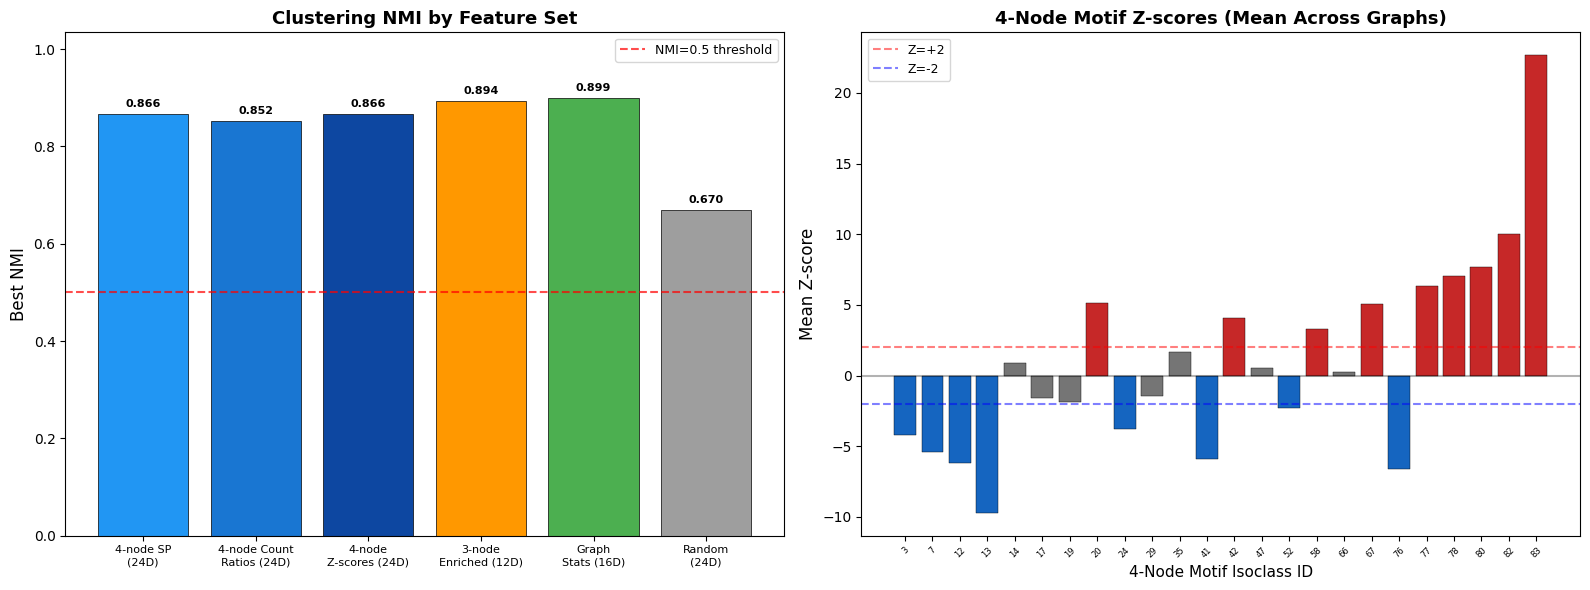

Saved motif_analysis_results.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Plot 1: Clustering NMI comparison ----
ax1 = axes[0]
feature_set_names = ["4node_sp_24d", "4node_count_ratios_24d", "4node_zscores_24d",
                     "3node_enriched_12d", "graph_stats_16d", "random_24d"]
display_names = ["4-node SP\n(24D)", "4-node Count\nRatios (24D)", "4-node\nZ-scores (24D)",
                 "3-node\nEnriched (12D)", "Graph\nStats (16D)", "Random\n(24D)"]
nmis = [clustering_results.get(n, {}).get("best_nmi", 0.0) for n in feature_set_names]

colors = ['#2196F3', '#1976D2', '#0D47A1', '#FF9800', '#4CAF50', '#9E9E9E']
bars = ax1.bar(range(len(nmis)), nmis, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_xticks(range(len(display_names)))
ax1.set_xticklabels(display_names, fontsize=8)
ax1.set_ylabel("Best NMI", fontsize=12)
ax1.set_title("Clustering NMI by Feature Set", fontsize=13, fontweight='bold')
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='NMI=0.5 threshold')
ax1.legend(fontsize=9)
ax1.set_ylim(0, max(nmis) * 1.15 if nmis and max(nmis) > 0 else 1.0)
for bar, nmi in zip(bars, nmis):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{nmi:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ---- Plot 2: Mean 4-node Z-scores per motif type ----
ax2 = axes[1]
if results_4node:
    motif_ids = sorted(dag_valid_4)
    mean_zs = []
    for mid in motif_ids:
        z_vals = [results_4node[gi]["z_scores"][mid] for gi in results_4node]
        mean_zs.append(np.mean(z_vals) if z_vals else 0.0)

    bar_colors = ['#C62828' if z > 2 else '#1565C0' if z < -2 else '#757575' for z in mean_zs]
    ax2.bar(range(len(motif_ids)), mean_zs, color=bar_colors, edgecolor='black', linewidth=0.3)
    ax2.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='Z=+2')
    ax2.axhline(y=-2, color='blue', linestyle='--', alpha=0.5, label='Z=-2')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax2.set_xticks(range(len(motif_ids)))
    ax2.set_xticklabels([str(m) for m in motif_ids], fontsize=6, rotation=45)
    ax2.set_xlabel("4-Node Motif Isoclass ID", fontsize=11)
    ax2.set_ylabel("Mean Z-score", fontsize=12)
    ax2.set_title("4-Node Motif Z-scores (Mean Across Graphs)", fontsize=13, fontweight='bold')
    ax2.legend(fontsize=9)
else:
    ax2.text(0.5, 0.5, "No 4-node results\n(all graphs too large)", ha='center', va='center',
             transform=ax2.transAxes, fontsize=14)

plt.tight_layout()
plt.savefig("motif_analysis_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved motif_analysis_results.png")